In [1]:
# Local steps to run in pycharm
# conda activate sage
# jupyter lab --no-browser --port=8888
# configure external server with the token
# sagemath (10.7)

from sage.all import *
from sage.plot.plot import graphics_array
from itertools import combinations
import matplotlib.pyplot as plt

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'savefig.facecolor': 'white',
})

def graph_square(H):
    G = Graph()
    G.add_vertices(H.vertices())
    for u in H.vertices():
        for v in H.vertices():
            if u < v and H.distance(u,v) <= 2:
                G.add_edge(u,v)
    return G

def is_square_root(G, H):
    return graph_square(H) == G

def find_square_root(G):
    V = list(G.vertices())
    n = len(V)
    pairs = list(combinations(range(n), 2))

    total = 1 << len(pairs)
    for mask in range(total):
        H = Graph()
        H.add_vertices(V)
        for bit, (i, j) in enumerate(pairs):
            if (mask >> bit) & 1:
                H.add_edge(V[i], V[j])
        if is_square_root(G, H):
            return H
    return None

def find_all_square_roots(G):

    V = list(G.vertices())
    n = len(V)

    edges_G = set(tuple(sorted(e)) for e in G.edges(labels=False))

    from itertools import combinations
    all_edges = list(combinations(V,2))

    labeled_count = 0
    canonical_roots = {}

    def backtrack(idx, current_edges):

        nonlocal labeled_count

        if idx == len(all_edges):

            H = Graph()
            H.add_vertices(V)
            H.add_edges(current_edges)

            H2 = graph_square(H)
            edges_H2 = set(tuple(sorted(e)) for e in H2.edges(labels=False))

            if edges_H2 == edges_G:

                labeled_count += 1

                canon = H.canonical_label()
                key = canon.graph6_string()

                if key not in canonical_roots:
                    canonical_roots[key] = H.copy()

            return

        u,v = all_edges[idx]

        new_edges = current_edges + [(u,v)]

        H_partial = Graph()
        H_partial.add_vertices(V)
        H_partial.add_edges(new_edges)

        H2 = graph_square(H_partial)

        valid = True
        for e in H2.edges(labels=False):
            if tuple(sorted(e)) not in edges_G:
                valid = False
                break

        if valid:
            backtrack(idx+1,new_edges)

        backtrack(idx+1,current_edges)

    backtrack(0,[])

    return {
        "labeled": labeled_count,
        "non_isomorphic": list(canonical_roots.values()),
        "non_isomorphic_count": len(canonical_roots),
    }

In [2]:
# Efficient find_square_root function

def violates_partial(G, H):
    for u, v in combinations(H.vertices(), 2):
        try:
            d = H.distance(u, v)
        except (ValueError, RuntimeError):
            continue

        if H.has_edge(u, v) and not G.has_edge(u, v):
            return True
        if d <= 2 and not G.has_edge(u, v):
            return True
    return False

def find_square_root(G):
    V = list(G.vertices())
    pairs = list(combinations(V, 2))
    H = Graph()
    H.add_vertices(V)

    def backtrack(idx):
        if idx == len(pairs):
            return H.copy() if is_square_root(G, H) else None

        u, v = pairs[idx]

        H.add_edge(u, v)
        if not violates_partial(G, H):
            result = backtrack(idx + 1)
            if result:
                return result
        H.delete_edge(u, v)

        if not violates_partial(G, H):
            result = backtrack(idx + 1)
            if result:
                return result

        return None

    return backtrack(0)


def find_all_square_roots(G):

    V = list(G.vertices())
    n = len(V)

    edges_G = set(tuple(sorted(e)) for e in G.edges(labels=False))

    from itertools import combinations
    all_edges = list(combinations(V,2))

    labeled_count = 0
    canonical_roots = {}

    def backtrack(idx, current_edges):

        nonlocal labeled_count

        if idx == len(all_edges):

            H = Graph()
            H.add_vertices(V)
            H.add_edges(current_edges)

            H2 = graph_square(H)
            edges_H2 = set(tuple(sorted(e)) for e in H2.edges(labels=False))

            if edges_H2 == edges_G:

                labeled_count += 1

                canon = H.canonical_label()
                key = canon.graph6_string()

                if key not in canonical_roots:
                    canonical_roots[key] = H.copy()

            return


        u,v = all_edges[idx]

        new_edges = current_edges + [(u,v)]

        H_partial = Graph()
        H_partial.add_vertices(V)
        H_partial.add_edges(new_edges)

        H2 = graph_square(H_partial)

        valid = True
        for e in H2.edges(labels=False):
            if tuple(sorted(e)) not in edges_G:
                valid = False
                break

        if valid:
            backtrack(idx+1,new_edges)

        backtrack(idx+1,current_edges)

    backtrack(0,[])

    return {
        "labeled": labeled_count,
        "non_isomorphic": list(canonical_roots.values())
    }

# LP with max objective function
def max_linear_program(G):
    m = MixedIntegerLinearProgram(solver='Gurobi', maximization=False)
    m.solver_parameter("Method", 2)

    x = m.new_variable(real=True, nonnegative=True)
    y = m.new_variable(real=True, nonnegative=True)
    z = m.new_variable(real=True, nonnegative=True)

    A_G = G.adjacency_matrix()
    n = A_G.nrows()
    M = n**2

    # Indicator argument
    for i in range(n):
        for j in range(n):
            if i == j:
                m.add_constraint(z[i,j] - (sum(y[i,k,j] for k in range(n)) - sum(x[i,k] for k in range(n)) + x[i,j]) == 0)
            else:
                m.add_constraint(z[i,j] - (sum(y[i,k,j] for k in range(n)) + x[i,j]) == 0)

    # Indicator function
    for i in range(n):
        for j in range(n):
            m.add_constraint(z[i,j] - M * A_G[i][j] <= 0)
            m.add_constraint(-z[i,j] + A_G[i][j] <= 0)

    # Product
    for i in range(n):
        for j in range(n):
            for k in range(n):
                m.add_constraint(y[i,k,j] - x[i,k] <= 0)
                m.add_constraint(y[i,k,j] - x[k,j] <= 0)
                m.add_constraint(- y[i,k,j] + x[i,k] + x[k,j] - 1 <= 0)

    # Symmetry
    for i in range(n):
        for j in range(n):
            m.add_constraint(x[i,j] == x[j,i])

    # Diagonal
    for i in range(n):
        m.add_constraint(x[i,i] == 0)

    # Variables
    for i in range(n):
        for j in range(n):
            m.add_constraint(x[i,j] - 1 <= 0)
            for k in range(n):
                m.add_constraint(y[i,k,j] - 1 <= 0)

    m.set_objective(- m.sum(x[i,j] for i in range(n) for j in range(n)))
    return m, x

In [3]:
from collections import defaultdict

def two_edge_triangles_from_edges(G):
    A = G.adjacency_matrix()
    n = G.num_verts()
    triangles = []
    for u in range(n):
        for v in range(u + 1, n):
            for w in range(v + 1, n):
                edges = A[u][v] + A[u][w] + A[v][w]
                if edges == 2:
                    triangles.append((u, v, w))
    return triangles

def present_edges(i, j, k, G):
    A = G.adjacency_matrix()
    edges = []
    if A[i][j]:
        edges.append((i, j))
    if A[i][k]:
        edges.append((i, k))
    if A[j][k]:
        edges.append((j, k))
    return edges

def is_fixed(value, tol=1e-8):
    return abs(value) < tol or abs(value - 1) < tol

def invalid_group(G, group_edges):
    group_edges = {tuple(sorted(e)) for e in group_edges}
    for v in G.vertices():
        incident_edges = {tuple(sorted(e)) for e in G.edges_incident(v, labels=False)}
        if not incident_edges:
            continue
        if incident_edges.issubset(group_edges):
            return True
    return False

def find_consistent_inconsistent_sets(G, solution=None):
    triangles = two_edge_triangles_from_edges(G)
    H = Graph()
    for tri in triangles:
        e1, e2 = present_edges(*tri, G)
        if solution is not None:
            if is_fixed(solution[e1]):
                continue
            if is_fixed(solution[e2]):
                continue
        H.add_vertex(e1)
        H.add_vertex(e2)
        H.add_edge(e1, e2)
    consistent_sets = []
    inconsistent_sets = []
    for component in H.connected_components():
        C = H.subgraph(component)
        if C.num_verts() < 3:
            continue
        group_edges = sorted(component)
        if C.is_bipartite():
            if invalid_group(G, group_edges):
                inconsistent_sets.append({
                    "edges": group_edges,
                })
                continue
            part0, part1 = C.bipartite_sets()
            consistent_sets.append({
                "edges": group_edges,
                "part0": sorted(part0),
                "part1": sorted(part1),
            })
        else:
            inconsistent_sets.append({
                "edges": group_edges,
            })
    return consistent_sets, inconsistent_sets

def edge_enforcement(G):
    consistent_sets, inconsistent_sets = find_consistent_inconsistent_sets(G)
    consistent_assignment = {}
    inconsistent_assignment = {}
    consistent_variables = []
    inconsistent_variables = []
    next_var = 0
    # Consistent sets
    for group in consistent_sets:
        a = var(f"a{next_var}")
        next_var += 1
        consistent_variables.append(a)
        for edge in group["part0"]:
            consistent_assignment[edge] = a
        for edge in group["part1"]:
            consistent_assignment[edge] = 1 - a
    # Inconsistent sets
    for group in inconsistent_sets:
        b = var(f"b{next_var}")
        next_var += 1
        inconsistent_variables.append(b)
        for edge in group["edges"]:
            inconsistent_assignment[edge] = b

    return consistent_assignment, inconsistent_assignment, consistent_variables, inconsistent_variables, consistent_sets, inconsistent_sets

def max_edge_enforcement_no_fixing_linear_program(G, verbose=False):
    m, x = max_linear_program(G)

    triangles = two_edge_triangles_from_edges(G)
    consistent_assignment, inconsistent_assignment, consistent_vars, inconsistent_vars, consistent_sets, inconsistent_sets = edge_enforcement(G)

    assignment = { **consistent_assignment, **inconsistent_assignment}
    variables = consistent_vars + inconsistent_vars

    if verbose:
        print("=" * 60)
        print("Edge Enforcement")

        print(f"Two-edge triangles ({len(triangles)}):")
        for t in triangles:
            print(f"  {t}")

        print(f"\nConsistent variables ({len(consistent_vars)}):")
        for a in consistent_vars:
            print(f"  {a}")

        print(f"\nInconsistent variables ({len(inconsistent_vars)}):")
        for b in inconsistent_vars:
            print(f"  {b}")

        print("\nConsistent edge assignments:")
        for edge in sorted(consistent_assignment):
            print(f"  {edge} -> {consistent_assignment[edge]}")

        print("\nInconsistent edge assignments:")
        for edge in sorted(inconsistent_assignment):
            print(f"  {edge} -> {inconsistent_assignment[edge]}")

        print("\nConsistent sets:")
        for i, group in enumerate(consistent_sets, 1):
            print(f"\nGroup {i}")
            print(f"  Variable : {consistent_vars[i-1]}")
            print(f"  Part 0   : {group['part0']}")
            print(f"  Part 1   : {group['part1']}")

        print("\nInconsistent sets:")
        for i, group in enumerate(inconsistent_sets, 1):
            print(f"\nGroup {i}")
            print(f"  Variable : {inconsistent_vars[i-1]}")
            print(f"  Edges    : {group['edges']}")

        print("=" * 60)

    var_index = {v: i for i, v in enumerate(variables)}

    group_lp = m.new_variable(real=True)

    for i in range(len(variables)):
        m.add_constraint(group_lp[i] >= 0)
        m.add_constraint(group_lp[i] <= 1)

    for group, a in zip(consistent_sets, consistent_vars):
        idx = var_index[a]
        for edge in group["part0"]:
            m.add_constraint(x[edge] == group_lp[idx])
        for edge in group["part1"]:
            m.add_constraint(x[edge] == 1 - group_lp[idx])

    return m, x, group_lp, variables, assignment


def choose_inconsistent_star(G, inconsistent_sets):
    if not inconsistent_sets:
        return None
    for group in inconsistent_sets:
        stars = defaultdict(list)
        for u, v in group["edges"]:
            edge = tuple(sorted((u, v)))
            stars[u].append(edge)
            stars[v].append(edge)
        if not stars:
            continue
        centre = max(stars, key=lambda v: (len(stars[v]), -v))
        return {
            "centre": centre,
            "edges": sorted(stars[centre])
        }
    return None

def choose_star_edge(star, solution_x):
    edges = sorted(star["edges"])
    return min(edges, key=lambda e: (min(solution_x[e], 1 - solution_x[e]), e))

def choose_consistent_group(consistent_sets):
    if not consistent_sets:
        return None
    return sorted(consistent_sets, key=lambda g: sorted(g))[0]

def choose_group_symbol(group):
    return min(group["edges"])


def max_edge_enforcement_fixing_linear_program(G, verbose=False):
    m, x, a_lp, variables, assignment = max_edge_enforcement_no_fixing_linear_program(G, verbose)
    n = G.order()

    try:
        m.solve()
    except MIPSolverException:
        if verbose:
            print("LP is infeasible.")
        return m, x

    solution_x = m.get_values(x)
    is_noninteger = False
    A_H = matrix([[solution_x[i, j] for j in range(n)] for i in range(n)])
    if any(abs(A_H[i, j] - round(A_H[i, j])) > 1e-6 for i in range(n) for j in range(n)):
        is_noninteger = True

    if verbose:
        print()
        print("Original LP: feasible")
        print("Original LP:", "fractional" if is_noninteger else "integral")

    if not is_noninteger:
        return m, x

    consistent_assignment, inconsistent_assignment, consistent_vars, inconsistent_vars, consistent_sets, inconsistent_sets = edge_enforcement(G)
    var_index = { v: i for i, v in enumerate(variables) }

    if consistent_sets:
        group = choose_consistent_group(consistent_sets)
        group_index = consistent_sets.index(group)
        symbol = consistent_vars[group_index]
        idx = var_index[symbol]
        if verbose:
            print()
            print("Selected consistent group:")
            print("  Variable:", symbol)
            print("  Part 0  :", group["part0"])
            print("  Part 1  :", group["part1"])
        m.add_constraint(a_lp[idx] == 0)
        try:
            m.solve()
            if verbose:
                print("Trying", symbol, "= 0")
                print("  -> feasible")
            return m, x
        except MIPSolverException:
            if verbose:
                print("Trying", symbol, "= 0")
                print("  -> infeasible")

        m, x, a_lp, variables, assignment = max_edge_enforcement_no_fixing_linear_program(G, verbose)
        m.add_constraint(a_lp[idx] == 1)
        try:
            m.solve()
            if verbose:
                print("Trying", symbol, "= 1")
                print("  -> feasible")
            return m, x
        except MIPSolverException:
            if verbose:
                print("Trying", symbol, "= 1")
                print("  -> infeasible")
    if inconsistent_sets:
        star = choose_inconsistent_star(G, inconsistent_sets)
        if star is None:
            if verbose:
                print("No valid inconsistent star found.")
            return m, x
        if verbose:
            print()
            print("Inconsistent sets detected.")
            print("Selected inconsistent star:")
            print("  Centre:", star["centre"])
            print("  Edges:", star["edges"])

        for edge in sorted(star["edges"]):
            value = int(solution_x[edge] >= 0.5)
            if verbose:
                print()
                print("No consistent sets.")
                print("Selected inconsistent star:")
                print("  Edges:", star["edges"])
                print("Selected star edge:", edge)
                print("LP value:", solution_x[edge])
                print("Fixing:", edge, "=", value)

            m_branch, x_branch, a_lp_branch, variables_branch, assignment_branch = max_edge_enforcement_no_fixing_linear_program(G, verbose)
            m_branch.add_constraint(x_branch[edge] == value)
            try:
                m_branch.solve()
                if verbose:
                    print("Star-fixed LP: feasible")
                return m_branch, x_branch

            except MIPSolverException:
                if verbose:
                    print("Star-fixed LP: infeasible")
                    print("Trying next star edge...")
                continue
    if verbose:
        print()
        print("No consistent or inconsistent sets.")
    return m, x

def max_edge_enforcement_iterative_linear_program(G, verbose=False):
    m, x, a_lp, variables, assignment = max_edge_enforcement_no_fixing_linear_program(G, verbose)
    n = G.order()

    consistent_assignment, inconsistent_assignment, consistent_vars, inconsistent_vars, consistent_sets, inconsistent_sets = edge_enforcement(G)
    var_index = {v: i for i, v in enumerate(variables)}
    fixed_consistent_sets = set()
    fixed_inconsistent_sets = set()
    fixed_constraints = []

    if verbose:
        print()
        print("Initial sets")
        print("  Consistent sets:", len(consistent_sets))
        print("  Inconsistent sets:", len(inconsistent_sets))

    while True:
        try:
            m.solve()
        except MIPSolverException:
            if verbose:
                print("LP is infeasible.")
            return m, x

        solution_x = m.get_values(x)
        is_noninteger = any(abs(solution_x[i, j] - round(solution_x[i, j])) > 1e-6 for i in range(n) for j in range(n))

        if verbose:
            print()
            print("Current LP: feasible")
            print("Current LP:", "fractional" if is_noninteger else "integral")

        if not is_noninteger:
            return m, x

        available_consistent_sets = [(i, group) for i, group in enumerate(consistent_sets) if i not in fixed_consistent_sets]
        available_inconsistent_sets = [(i, group) for i, group in enumerate(inconsistent_sets) if i not in fixed_inconsistent_sets]

        if available_consistent_sets:
            group_index, group = available_consistent_sets[0]
            symbol = consistent_vars[group_index]
            idx = var_index[symbol]

            if verbose:
                print()
                print("Selected consistent group:")
                print("  Variable:", symbol)
                print("  Part 0  :", group["part0"])
                print("  Part 1  :", group["part1"])

            m0, x0, a0, variables0, assignment0 = max_edge_enforcement_no_fixing_linear_program(G, verbose)
            var_index0 = {v: i for i, v in enumerate(variables0)}

            for fixed_type, fixed_value in fixed_constraints:
                if fixed_type == "a":
                    m0.add_constraint(a0[var_index0[fixed_value[0]]] == fixed_value[1])
                else:
                    m0.add_constraint(x0[fixed_value[0]] == fixed_value[1])

            m0.add_constraint(a0[var_index0[symbol]] == 0)

            try:
                m0.solve()

                if verbose:
                    print("Trying", symbol, "= 0")
                    print("  -> feasible")

                m = m0
                x = x0
                a_lp = a0
                variables = variables0
                assignment = assignment0

                fixed_constraints.append(("a", (symbol, 0)))
                fixed_consistent_sets.add(group_index)

                solution_x = m.get_values(x)
                is_noninteger = any(abs(solution_x[i, j] - round(solution_x[i, j])) > 1e-6 for i in range(n) for j in range(n))

                if verbose:
                    print("After fixing", symbol, "= 0:", "fractional" if is_noninteger else "integral")

                if not is_noninteger:
                    return m, x

                continue

            except MIPSolverException:
                if verbose:
                    print("Trying", symbol, "= 0")
                    print("  -> infeasible")

            m1, x1, a1, variables1, assignment1 = max_edge_enforcement_no_fixing_linear_program(G, verbose)
            var_index1 = {v: i for i, v in enumerate(variables1)}

            for fixed_type, fixed_value in fixed_constraints:
                if fixed_type == "a":
                    m1.add_constraint(a1[var_index1[fixed_value[0]]] == fixed_value[1])
                else:
                    m1.add_constraint(x1[fixed_value[0]] == fixed_value[1])

            m1.add_constraint(a1[var_index1[symbol]] == 1)

            try:
                m1.solve()

                if verbose:
                    print("Trying", symbol, "= 1")
                    print("  -> feasible")

                m = m1
                x = x1
                a_lp = a1
                variables = variables1
                assignment = assignment1

                fixed_constraints.append(("a", (symbol, 1)))
                fixed_consistent_sets.add(group_index)

                solution_x = m.get_values(x)
                is_noninteger = any(abs(solution_x[i, j] - round(solution_x[i, j])) > 1e-6 for i in range(n) for j in range(n))

                if verbose:
                    print("After fixing", symbol, "= 1:", "fractional" if is_noninteger else "integral")

                if not is_noninteger:
                    return m, x

                continue

            except MIPSolverException:
                if verbose:
                    print("Trying", symbol, "= 1")
                    print("  -> infeasible")

            fixed_consistent_sets.add(group_index)

            if verbose:
                print("Both branches infeasible for", symbol)

            continue

        if available_inconsistent_sets:
            group_index, group = available_inconsistent_sets[0]
            star = choose_inconsistent_star(G, [group])

            if star is None:
                if verbose:
                    print("No valid inconsistent star found.")
                fixed_inconsistent_sets.add(group_index)
                continue

            if verbose:
                print()
                print("Inconsistent sets detected.")
                print("Selected inconsistent star:")
                print("  Centre:", star["centre"])
                print("  Edges:", star["edges"])

            branch_found = False

            for edge in sorted(star["edges"]):
                value = 1

                if verbose:
                    print()
                    print("No consistent sets.")
                    print("Selected inconsistent star:")
                    print("  Edges:", star["edges"])
                    print("Selected star edge:", edge)
                    print("Fixing:", edge, "=", value)

                m_branch, x_branch, a_lp_branch, variables_branch, assignment_branch = max_edge_enforcement_no_fixing_linear_program(G, verbose)
                var_index_branch = {v: i for i, v in enumerate(variables_branch)}

                for fixed_type, fixed_value in fixed_constraints:
                    if fixed_type == "a":
                        m_branch.add_constraint(a_lp_branch[var_index_branch[fixed_value[0]]] == fixed_value[1])
                    else:
                        m_branch.add_constraint(x_branch[fixed_value[0]] == fixed_value[1])

                m_branch.add_constraint(x_branch[edge] == 1)

                try:
                    m_branch.solve()

                    if verbose:
                        print("Star-fixed LP: feasible")

                    m = m_branch
                    x = x_branch
                    a_lp = a_lp_branch
                    variables = variables_branch
                    assignment = assignment_branch

                    fixed_constraints.append(("x", (edge, 1)))
                    fixed_inconsistent_sets.add(group_index)

                    solution_x = m.get_values(x)
                    is_noninteger = any(abs(solution_x[i, j] - round(solution_x[i, j])) > 1e-6 for i in range(n) for j in range(n))

                    if verbose:
                        print("After fixing", edge, "= 1:", "fractional" if is_noninteger else "integral")

                    if not is_noninteger:
                        return m, x

                    branch_found = True
                    break

                except MIPSolverException:
                    if verbose:
                        print("Star-fixed LP: infeasible")
                        print("Trying next star edge...")
                    continue

            if not branch_found:
                fixed_inconsistent_sets.add(group_index)

            continue

        if verbose:
            print()
            print("No consistent or inconsistent sets remain.")
            print("LP is still fractional.")

        return m, x

In [4]:
# Generate all possible graph squares/roots for given n
import os
import itertools
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from sage.numerical.mip import MIPSolverException
from sage.graphs.graph_generators import graphs as graph_gens
from concurrent.futures import ThreadPoolExecutor, as_completed

n = 7
ncpus = 12
dir = f"max_edge_enforcement_iterative_graph_output"
output_dir = os.path.join(dir, f"n={n}")
output_pdf = os.path.join(output_dir, f"graph_results_n={n}.pdf")
comparison_pdf = os.path.join(output_dir, f"graph_comparison_n={n}.pdf")
summary_file = os.path.join(output_dir, f"graph_summary_n={n}.txt")

os.makedirs(output_dir, exist_ok=True)
os.makedirs(dir, exist_ok=True)

def error_plot(message):
    g = Graphics()
    g += text(message, (0, 0), fontsize=14, color="red", horizontal_alignment='center')
    g.axes(False)
    return g

def is_claw_free_graph(G):
    for v in G.vertices():
        N = G.neighbors(v)
        if len(N) < 3:
            continue
        for a in range(len(N)):
            for b in range(a+1, len(N)):
                for c in range(b+1, len(N)):
                    u1, u2, u3 = N[a], N[b], N[c]
                    if (not G.has_edge(u1, u2) and
                        not G.has_edge(u1, u3) and
                        not G.has_edge(u2, u3)):
                        return False
    return True

def is_dismantlable_graph(G):
    G_1 = G.copy()

    while G_1.order() > 1:
        found = False

        for v in G_1.vertices():
            Nv = set(G_1.neighbors(v)) | {v}

            for u in G_1.vertices():
                if u == v:
                    continue

                Nu = set(G_1.neighbors(u)) | {u}

                if Nv.issubset(Nu):
                    G_1.delete_vertex(v)
                    found = True
                    break

            if found:
                break

        if not found:
            return False

    return True

def graph_signature(G):
    return (
        G.order(),
        tuple(sorted(tuple(sorted(e)) for e in G.edges(labels=False)))
    )

def process_graph(idx, G, label, known_roots, num_total_roots):
    G.relabel(range(G.order()), inplace=True)
    n = G.order()

    A_H = None
    sol_H = None
    H = None
    lp_status = "unknown"
    has_root = False
    edges_H = None
    is_noninteger = False

    try:
        m, x = max_edge_enforcement_iterative_linear_program(G, verbose=True)
        # m, x = max_edge_enforcement_fixing_linear_program(G, false)
        # m, x, a_lp, variables, assignment = max_edge_enforcement_no_fixing_linear_program(G, true)
        m.solve()
        solution_x = m.get_values(x)
        A_H = matrix([[solution_x[i, j] for j in range(n)] for i in range(n)])
        sol_H = Graph(A_H, weighted=True)
        for (u, v, w) in sol_H.edges():
            sol_H.set_edge_label(u, v, round(w, 3))
        p1 = sol_H.plot(edge_labels=True, title='Weighted LP H')
        lp_status = "feasible"

        if any(abs(A_H[i, j] - round(A_H[i, j])) > 1e-6 for i in range(n) for j in range(n)):
            is_noninteger = True

    except MIPSolverException:
        sol_H = None
        p1 = error_plot("LP infeasible")
        lp_status = "infeasible"

    num_unique_roots = len(known_roots)
    has_root = num_unique_roots > 0
    H = known_roots[0] if has_root else None

    root_properties = {
        "is_tree": None,
        "is_bipartite": None,
        "is_proper_interval": None,
        "is_girth_more_than_six": None,
        "is_block": None,
        "is_comparability": None,
        "is_dismantlable": None
    }

    if H is None:
        p2 = error_plot("No feasible H")
        has_root = False
        edges_H = None
    else:
        p2 = H.plot(title='Feasible H')
        has_root = True
        edges_H = H.size()

        root_properties["is_tree"] = H.is_tree()
        root_properties["is_bipartite"] = H.is_bipartite()
        is_interval = H.is_interval()
        is_claw_free = is_claw_free_graph(H)
        root_properties["is_proper_interval"] = is_interval and is_claw_free

        if H.is_tree():
            root_properties["is_girth_more_than_six"] = True
        else:
            g = H.girth()
            root_properties["is_girth_more_than_six"] = (g is not None and g > 6)

        root_properties["is_block"] = H.is_block_graph()
        root_properties["is_comparability"] = H.is_comparability()
        root_properties["is_dismantlable"] = is_dismantlable_graph(H)

    p3 = G.plot(title=f"{label} G (#{idx})")

    summary = {
        "index": idx,
        "edges_G": G.size(),
        "vertices_G": n,
        "lp_status": lp_status,
        "has_root": has_root,
        "edges_H": H.size() if H else None,
        "is_noninteger": is_noninteger,
        "total_roots": num_total_roots,
        "unique_roots": num_unique_roots,
        **root_properties
    }

    is_mismatch = (is_noninteger or (lp_status == "feasible" and H is None))

    if is_mismatch:
        if sol_H is not None:
            p_left = sol_H.plot(edge_labels=True, title="Weighted LP H")
        else:
            p_left = error_plot("No LP solution")

        if H is not None:
            p_mid = H.plot(title="Feasible H")
        else:
            p_mid = error_plot("No discrete H")

        p_right = G.plot(title="Original G")
        comparison = graphics_array([p_left, p_mid, p_right])
    else:
        comparison = None

    return (p1, p2, p3), summary, comparison, is_mismatch


root_graphs = {}
all_graphs = []

for idx, G0 in enumerate(graph_gens.nauty_geng(str(n))):
    G = Graph(G0)
    G.relabel(range(G.order()))
    all_graphs.append((idx, G))

for H0 in graph_gens.nauty_geng(str(n)):
    H = Graph(H0)
    H.relabel(range(H.order()))

    G = graph_square(H)
    G.relabel(range(G.order()))

    key = G.canonical_label().graph6_string()

    if key not in root_graphs:
        root_graphs[key] = {"roots": [], "total": 0}

    root_graphs[key]["total"] += 1

    if not any(H.is_isomorphic(K) for K in root_graphs[key]["roots"]):
        root_graphs[key]["roots"].append(H)

root_tasks = []
no_root_tasks = []

for idx, G in all_graphs:
    key = G.canonical_label().graph6_string()

    if key in root_graphs:
        known_roots = root_graphs[key]["roots"]
        num_total_roots = root_graphs[key]["total"]
        root_tasks.append((idx, G, known_roots, num_total_roots))
    else:
        no_root_tasks.append((idx, G, [], 0))

tasks = root_tasks + no_root_tasks

print(f"Root classification: total={len(tasks)} | with roots={len(root_tasks)} | without roots={len(no_root_tasks)}")

def run_task(task):
    idx, G, known_roots, num_total_roots = task
    return idx, process_graph(idx, G, "Original", known_roots, num_total_roots)

results = []
mismatch_results = []
summary = {}
graph_info = {}



with ThreadPoolExecutor(max_workers=ncpus) as executor:
    futures = {executor.submit(run_task, task): task[0] for task in tasks}

    for future in as_completed(futures):
        idx, result = future.result()
        plot_G, summary_G, comp_G, mismatch_G = result

        if mismatch_G and comp_G is not None:
            mismatch_results.append((comp_G, summary_G))

        p1, p2, p3 = plot_G
        results.append((graphics_array([[p1, p2, p3]]), summary_G))

        H_exists = summary_G["has_root"]

        if summary_G["lp_status"] == "infeasible":
            LP_type = "LP infeasible"
        elif summary_G["is_noninteger"]:
            LP_type = "LP fractional"
        else:
            LP_type = "LP integer"

        summary.setdefault((H_exists, LP_type), []).append(idx)

        graph_info[idx] = {
            "H_exists": H_exists,
            "LP_type": LP_type,
            "TotalRoots": summary_G["total_roots"],
            "NonIsoRoots": summary_G["unique_roots"],
            "Tree": "Yes" if summary_G["is_tree"] else "No",
            "Bip": "Yes" if summary_G["is_bipartite"] else "No",
            "PropInt": "Yes" if summary_G["is_proper_interval"] else "No",
            "Girth>6": "Yes" if summary_G["is_girth_more_than_six"] else "No",
            "Block": "Yes" if summary_G["is_block"] else "No",
            "Comparability": "Yes" if summary_G["is_comparability"] else "No",
            "Dismantlable": "Yes" if summary_G["is_dismantlable"] else "No"
        }

        print(f"Graph {summary_G['index']:>4} | LP={summary_G['lp_status']:<10} | Root={'Yes' if summary_G['has_root'] else 'No':<3} | NonInt={'Yes' if summary_G['is_noninteger'] else 'No':<3} | {'MISMATCH' if mismatch_G else 'OK'}")


if n < 8:
    with open(summary_file, "w") as f:
        header = f"{'Graph':>5} | {'Verts':>5} | {'Edges(G)':>8} | {'Roots':>7} | {'NonIso':>7} | {'Edges(H)':>8} | {'LP':>12} | {'Root':>5} | {'NonInt':>7} | {'Tree':>5} | {'Bip':>5} | {'PropInt':>7} | {'Girth>6':>8} | {'Block':>5} | {'Comparability':>13} | {'Dismantlable':>12}\n"
        f.write(header)
        f.write("-" * len(header) + "\n")
        for _, s in sorted(results, key=lambda z: z[1]["index"]):
            f.write(f"{s['index']:>5} | {s['vertices_G']:>5} | {s['edges_G']:>8} | {s['total_roots']:>7} | {s['unique_roots']:>7} | {str(s['edges_H']) if s['edges_H'] is not None else 'NA':>8} | {s['lp_status']:<12} | {'Yes' if s['has_root'] else 'No':>5} | {'Yes' if s['is_noninteger'] else 'No':>7} | {'Yes' if s['is_tree'] else 'No':>5} | {'Yes' if s['is_bipartite'] else 'No':>5} | {'Yes' if s['is_proper_interval'] else 'No':>7} | {'Yes' if s['is_girth_more_than_six'] else 'No':>8} | {'Yes' if s['is_block'] else 'No':>5} | {'Yes' if s['is_comparability'] else 'No':>13} | {'Yes' if s['is_dismantlable'] else 'No':>12}\n")
            f.write("-" * len(header) + "\n")
    print(f"Summary written to {summary_file}")

if n < 8:
    analysis_file = os.path.join(output_dir, f"graph_analysis_n={n}.txt")

    with open(analysis_file, "w", encoding="utf-8") as f:
        f.write("==============================\n")
        f.write("Root Classification\n")
        f.write("==============================\n")

        for (H_exists, LP_type), graphs in sorted(summary.items()):
            f.write(f"H exists: {str(H_exists):<5} | {LP_type:<15} → {len(graphs)} graphs\n")

        properties = [
            ("Tree", "Tree"),
            ("Bip", "Bipartite"),
            ("PropInt", "Proper Interval"),
            ("Girth>6", "Girth > 6"),
            ("Block", "Block Graph"),
            ("Comparability", "Comparability"),
            ("Dismantlable", "Dismantlable")
        ]

        f.write("\n==============================\n")
        f.write("Fractional LP Analysis\n")
        f.write("==============================\n")

        for key, label in properties:
            H_true_yes = H_true_no = H_false_yes = H_false_no = 0

            for info in graph_info.values():
                if info["LP_type"] != "LP fractional":
                    continue

                if info["H_exists"]:
                    if info[key] == "Yes":
                        H_true_yes += 1
                    else:
                        H_true_no += 1
                else:
                    if info[key] == "Yes":
                        H_false_yes += 1
                    else:
                        H_false_no += 1

            f.write(f"\n{label} for fractional solutions\n")
            f.write(f"H=True  | {label}=Yes → {H_true_yes}\n")
            f.write(f"H=True  | {label}=No  → {H_true_no}\n")
            f.write(f"H=False | {label}=Yes → {H_false_yes}\n")
            f.write(f"H=False | {label}=No  → {H_false_no}\n")

        f.write("\n==============================\n")
        f.write("Fractional Solutions with Roots\n")
        f.write("==============================\n")

        for idx in sorted(graph_info):
            info = graph_info[idx]

            if info["LP_type"] != "LP fractional" or not info["H_exists"]:
                continue

            warning = (
                info["Tree"] == "No"
                and info["Bip"] == "No"
                and info["PropInt"] == "No"
                and info["Girth>6"] == "No"
                and info["Block"] == "No"
            )

            warn_symbol = " ⚠" if warning else ""

            f.write(f"\nGraph {idx}{warn_symbol}\n")
            f.write(f"  Original → H exists: {info['H_exists']} | {info['LP_type']}\n")
            f.write(f"  Roots: {info['TotalRoots']}\n")
            f.write(
                f"  Properties: Tree={info['Tree']} "
                f"Bip={info['Bip']} "
                f"PI={info['PropInt']} "
                f"Girth>6={info['Girth>6']} "
                f"Block={info['Block']} "
                f"Comparability={info['Comparability']} "
                f"Dismantlable={info['Dismantlable']}\n"
            )

    print(f"Analysis written to {analysis_file}")

    with PdfPages(output_pdf) as pdf:
        for p, sG in results:
            fig = p.matplotlib(figsize=(12, 4))
            pdf.savefig(fig)
            plt.close(fig)

    print(f"Combined {len(results)} graphs into {output_pdf}")

    if mismatch_results:
        with PdfPages(comparison_pdf) as pdf:
            for comp, s in mismatch_results:
                fig = comp.matplotlib(figsize=(12, 4))
                plt.suptitle(
                    f"Graph {s['index']} | "
                    f"LP={s['lp_status']} | "
                    f"Root={s['has_root']} | "
                    f"{'Non-integer LP' if s['is_noninteger'] else ''}"
                )
                pdf.savefig(fig)
                plt.close(fig)

        print(f"Comparison mismatches saved to {comparison_pdf}")

else:
    print("==============================")
    print("Root Classification")
    print("==============================")

    for (H_exists, LP_type), graphs in sorted(summary.items()):
        print(f"H exists: {str(H_exists):<5} | {LP_type:<15} → {len(graphs)} graphs")

    properties = [
        ("Tree", "Tree"),
        ("Bip", "Bipartite"),
        ("PropInt", "Proper Interval"),
        ("Girth>6", "Girth > 6"),
        ("Block", "Block Graph"),
        ("Comparability", "Comparability"),
        ("Dismantlable", "Dismantlable")
    ]

    print("\n==============================")
    print("Fractional LP Analysis")
    print("==============================")

    for key, label in properties:
        H_true_yes = H_true_no = H_false_yes = H_false_no = 0

        for info in graph_info.values():
            if info["LP_type"] != "LP fractional":
                continue

            if info["H_exists"]:
                if info[key] == "Yes":
                    H_true_yes += 1
                else:
                    H_true_no += 1
            else:
                if info[key] == "Yes":
                    H_false_yes += 1
                else:
                    H_false_no += 1

        print(f"\n{label} for fractional solutions")
        print(f"H=True  | {label}=Yes → {H_true_yes}")
        print(f"H=True  | {label}=No  → {H_true_no}")
        print(f"H=False | {label}=Yes → {H_false_yes}")
        print(f"H=False | {label}=No  → {H_false_no}")

    print("\n==============================")
    print("Fractional Solutions with Roots")
    print("==============================")

    for idx in sorted(graph_info):
        info = graph_info[idx]

        if info["LP_type"] != "LP fractional" or not info["H_exists"]:
            continue

        warning = (
            info["Tree"] == "No"
            and info["Bip"] == "No"
            and info["PropInt"] == "No"
            and info["Girth>6"] == "No"
            and info["Block"] == "No"
        )

        warn_symbol = " ⚠" if warning else ""

        print(f"\nGraph {idx}{warn_symbol}")
        print(f"  Original → H exists: {info['H_exists']} | {info['LP_type']}")
        print(f"  Roots: {info['TotalRoots']}")
        print(
            f"  Properties: Tree={info['Tree']} "
            f"Bip={info['Bip']} "
            f"PI={info['PropInt']} "
            f"Girth>6={info['Girth>6']} "
            f"Block={info['Block']} "
            f"Comparability={info['Comparability']} "
            f"Dismantlable={info['Dismantlable']}"
        )

Root classification: total=1044 | with roots=77 | without roots=967
Edge Enforcement
Two-edge triangles (5):
  (0, 1, 5)
  (0, 1, 6)
  (0, 4, 5)
  (1, 4, 6)
  (4, 5, 6)

Consistent variables (1):
  a0

Inconsistent variables (1):
  b1

Consistent edge assignments:
  (0, 4) -> -a0 + 1
  (0, 5) -> a0
  (1, 5) -> -a0 + 1

Inconsistent edge assignments:
  (0, 6) -> b1
  (1, 6) -> b1
  (4, 6) -> b1
  (5, 6) -> b1

Consistent sets:

Group 1
  Variable : a0
  Part 0   : [(0, 5)]
  Part 1   : [(0, 4), (1, 5)]

Inconsistent sets:

Group 1
  Variable : b1
  Edges    : [(0, 6), (1, 6), (4, 6), (5, 6)]

Initial sets
  Consistent sets: 1
  Inconsistent sets: 1
Edge Enforcement
Two-edge triangles (0):

Consistent variables (0):

Inconsistent variables (0):

Consistent edge assignments:

Inconsistent edge assignments:

Consistent sets:

Inconsistent sets:

Initial sets
  Consistent sets: 0
  Inconsistent sets: 0

Current LP: feasible
Current LP: integral

Current LP: feasible
Current LP: integral
Edg

<Figure size 640x480 with 0 Axes>

In [5]:
n = 7
filename = f"max_edge_enforcement_iterative_graph_output/n={n}/graph_summary_n={n}.txt"

summary = {}
graph_info = {}
iso_effects = []
original_status = {}
current_graph = None
total_graphs = 0

with open(filename, "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()

        if not line or line.startswith("-") or line.startswith("SUMMARY") or line.startswith("Graph"):
            continue

        if line.startswith("ISO CHECK"):
            if current_graph is None:
                continue

            parts = [p.strip() for p in line.replace("ISO CHECK →", "").split("|")]

            iso_data = {}
            for p in parts:
                key, value = p.split("=")
                iso_data[key.strip()] = int(value.strip())

            graph_info[current_graph]["ISO"] = iso_data
            continue

        parts = [p.strip() for p in line.split("|")]

        if len(parts) != 16:
            continue

        (
            graph,
            verts,
            edges_g,
            roots_total,
            roots_unique,
            edges_h,
            lp,
            root,
            nonint,
            tree,
            bip,
            propint,
            girth6,
            block,
            comparability,
            dismantlable
        ) = parts

        idx = int(graph)
        current_graph = idx

        total_graphs += 1

        roots_total = int(roots_total)
        roots_unique = int(roots_unique)

        H_exists = (root == "Yes")

        if lp == "infeasible":
            LP_type = "LP infeasible"
        elif nonint == "Yes":
            LP_type = "LP fractional"
        else:
            LP_type = "LP integer"

        key = (H_exists, LP_type)
        summary.setdefault(key, []).append(idx)

        graph_info[idx] = {
            "H_exists": H_exists,
            "LP_type": LP_type,
            "TotalRoots": roots_total,
            "NonIsoRoots": roots_unique,
            "Tree": tree,
            "Bip": bip,
            "PropInt": propint,
            "Girth>6": girth6,
            "Block": block,
            "Comparability": comparability,
            "Dismantlable": dismantlable
        }

for (H_exists, LP_type), graphs in sorted(summary.items()):
    print(
        f"H exists: {str(H_exists):<5} | "
        f"{LP_type:<15} → "
        f"{len(graphs)} graphs"
    )

properties = [
    ("Tree", "Tree"),
    ("Bip", "Bipartite"),
    ("PropInt", "Proper Interval"),
    ("Girth>6", "Girth > 6"),
    ("Block", "Block Graph"),
    ("Comparability", "Comparability"),
    ("Dismantlable", "Dismantlable")
]

for key, label in properties:

    H_true_yes = 0
    H_true_no = 0
    H_false_yes = 0
    H_false_no = 0

    for info in graph_info.values():

        if info["LP_type"] != "LP fractional":
            continue

        H = info["H_exists"]
        val = info[key]

        if H:
            if val == "Yes":
                H_true_yes += 1
            else:
                H_true_no += 1
        else:
            if val == "Yes":
                H_false_yes += 1
            else:
                H_false_no += 1

    print(f"\n{label} for fractional solutions")
    print(f"H=True  | {label}=Yes → {H_true_yes}")
    print(f"H=True  | {label}=No  → {H_true_no}")
    print(f"H=False | {label}=Yes → {H_false_yes}")
    print(f"H=False | {label}=No  → {H_false_no}")

print()

for idx in sorted(graph_info):

    info = graph_info[idx]

    if not (not info["LP_type"] == "LP integer" and info["H_exists"]):
        continue

    warning = (
        info["Tree"] == "No"
        and info["Bip"] == "No"
        and info["PropInt"] == "No"
        and info["Girth>6"] == "No"
        and info["Block"] == "No"
    )

    warn_symbol = " ⚠" if warning else ""

    print(f"Graph {idx}{warn_symbol}")

    print(
        f"  Original → "
        f"H exists: {info['H_exists']} | "
        f"{info['LP_type']}"
    )

    print(
        f"  Roots: {info['TotalRoots']}"
    )

    print(
        f"  Properties: "
        f"Tree={info['Tree']} "
        f"Bip={info['Bip']} "
        f"PI={info['PropInt']} "
        f"Girth>6={info['Girth>6']} "
        f"Block={info['Block']} "
        f"Comparability={info['Comparability']} "
        f"Dismantlable={info['Dismantlable']}"
    )

    print()

H exists: False | LP fractional   → 200 graphs
H exists: False | LP infeasible   → 767 graphs
H exists: True  | LP fractional   → 10 graphs
H exists: True  | LP integer      → 67 graphs

Tree for fractional solutions
H=True  | Tree=Yes → 0
H=True  | Tree=No  → 10
H=False | Tree=Yes → 0
H=False | Tree=No  → 200

Bipartite for fractional solutions
H=True  | Bipartite=Yes → 10
H=True  | Bipartite=No  → 0
H=False | Bipartite=Yes → 0
H=False | Bipartite=No  → 200

Proper Interval for fractional solutions
H=True  | Proper Interval=Yes → 0
H=True  | Proper Interval=No  → 10
H=False | Proper Interval=Yes → 0
H=False | Proper Interval=No  → 200

Girth > 6 for fractional solutions
H=True  | Girth > 6=Yes → 0
H=True  | Girth > 6=No  → 10
H=False | Girth > 6=Yes → 0
H=False | Girth > 6=No  → 200

Block Graph for fractional solutions
H=True  | Block Graph=Yes → 0
H=True  | Block Graph=No  → 10
H=False | Block Graph=Yes → 0
H=False | Block Graph=No  → 200

Comparability for fractional solutions
H=Tr

Graph #1012


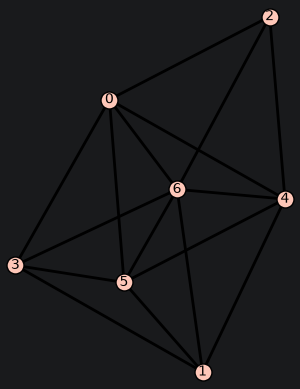

Edge Enforcement
Two-edge triangles (15):
  (0, 1, 3)
  (0, 1, 4)
  (0, 1, 5)
  (0, 1, 6)
  (0, 2, 3)
  (0, 2, 5)
  (0, 3, 4)
  (1, 2, 4)
  (1, 2, 6)
  (1, 3, 4)
  (2, 3, 6)
  (2, 4, 5)
  (2, 5, 6)
  (3, 4, 5)
  (3, 4, 6)

Consistent variables (1):
  a0

Inconsistent variables (1):
  b1

Consistent edge assignments:
  (0, 2) -> -a0 + 1
  (0, 3) -> a0
  (0, 4) -> -a0 + 1
  (0, 5) -> a0
  (1, 3) -> -a0 + 1
  (1, 4) -> a0
  (1, 5) -> -a0 + 1
  (2, 4) -> -a0 + 1
  (3, 5) -> -a0 + 1
  (4, 5) -> a0

Inconsistent edge assignments:
  (0, 6) -> b1
  (1, 6) -> b1
  (2, 6) -> b1
  (3, 6) -> b1
  (4, 6) -> b1
  (5, 6) -> b1

Consistent sets:

Group 1
  Variable : a0
  Part 0   : [(0, 3), (0, 5), (1, 4), (4, 5)]
  Part 1   : [(0, 2), (0, 4), (1, 3), (1, 5), (2, 4), (3, 5)]

Inconsistent sets:

Group 1
  Variable : b1
  Edges    : [(0, 6), (1, 6), (2, 6), (3, 6), (4, 6), (5, 6)]

Initial sets
  Consistent sets: 1
  Inconsistent sets: 1

Current LP: feasible
Current LP: fractional

Selected consisten

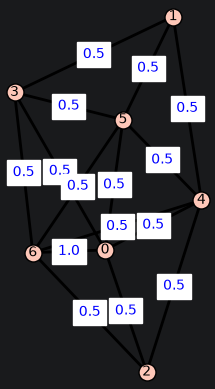

Square Roots
Number of labelled square roots: 2
Number of non-isomorphic square roots: 1

------------------------------------------------------------
Non-isomorphic square root 1
------------------------------------------------------------
Edges: [(0, 2), (0, 4), (0, 6), (1, 3), (1, 5), (3, 6), (4, 5), (5, 6)]


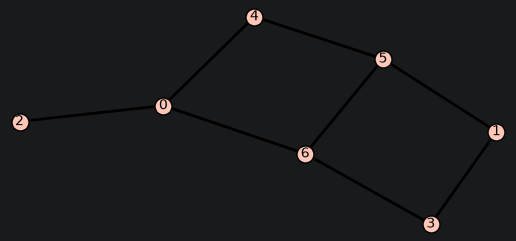

In [7]:
%matplotlib inline

from sage.all import Graph, graphs
from sage.numerical.mip import MIPSolverException

def display_graph(idx=None, n=None, G=None):

    if G is None:
        if idx is None or n is None:
            raise ValueError("Provide either G or (idx, n).")

        for i, g in enumerate(graphs.nauty_geng(str(n))):
            if i == idx:
                G = Graph(g)
                break

        if G is None:
            print("Graph not found.")
            return
    else:
        G = Graph(G)

    G.relabel(range(G.order()), inplace=True)

    print("="*80)
    print(f"Graph #{idx}")
    print("="*80)

    display(
        G.plot(
            vertex_labels=True,
            vertex_size=150,
            edge_thickness=2,
            title="G"
        ).matplotlib()
    )

    try:
        m, x = max_edge_enforcement_iterative_linear_program(G, true)
        # m, x, a_lp, variables, assignment = max_edge_enforcement_no_fixing_linear_program(G, true)
        m.solve()

        sol = m.get_values(x)

        eps = 1e-8

        A = matrix(
            [
                [
                    0 if abs(sol[i,j]) < eps else round(sol[i,j], 3)
                    for j in range(G.order())
                ]
                for i in range(G.order())
            ]
        )


        fractional = any(
            abs(A[i, j] - round(A[i, j])) > 1e-6
            for i in range(G.order())
            for j in range(G.order())
        )

        lp_type = "fractional" if fractional else "integer"

        H_lp = Graph(A, weighted=True)

        for (u, v, w) in H_lp.edges():
            H_lp.set_edge_label(u, v, round(w, 3))

        print("LP status: feasible")
        print("LP type:", lp_type)
        display(
            H_lp.plot(
                vertex_labels=True,
                edge_labels=True,
                vertex_size=150,
                edge_thickness=2,
                title="H"
            ).matplotlib()
        )

    except MIPSolverException:

        print("LP status: infeasible")
        lp_type = "infeasible"

        print("\n" + "=" * 80)
    print("Square Roots")
    print("=" * 80)

    roots = find_all_square_roots(G)

    labeled_count = roots["labeled"]
    non_isomorphic_roots = roots["non_isomorphic"]
    non_isomorphic_count = len(non_isomorphic_roots)

    print("Number of labelled square roots:",
          labeled_count)

    print("Number of non-isomorphic square roots:",
          non_isomorphic_count)

    for i, H in enumerate(non_isomorphic_roots, 1):

        print("\n" + "-" * 60)
        print(f"Non-isomorphic square root {i}")
        print("-" * 60)

        print("Edges:",
              sorted(H.edges(labels=False)))

        display(
            H.plot(
                vertex_labels=True,
                vertex_size=150,
                edge_thickness=2,
                title=f"Square root {i}"
            ).matplotlib()
        )

display_graph(1012, 7)

Graph #1013


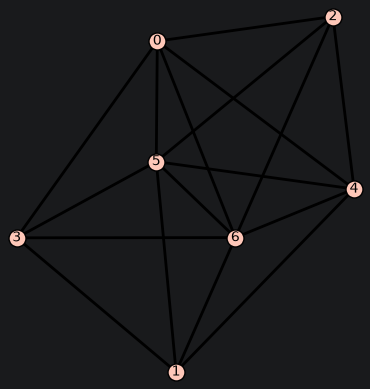

Edge Enforcement
Two-edge triangles (14):
  (0, 1, 3)
  (0, 1, 4)
  (0, 1, 5)
  (0, 1, 6)
  (0, 2, 3)
  (0, 3, 4)
  (1, 2, 4)
  (1, 2, 5)
  (1, 2, 6)
  (1, 3, 4)
  (2, 3, 5)
  (2, 3, 6)
  (3, 4, 5)
  (3, 4, 6)

Consistent variables (3):
  a0
  a1
  a2

Inconsistent variables (0):

Consistent edge assignments:
  (0, 2) -> -a0 + 1
  (0, 3) -> a0
  (0, 4) -> -a0 + 1
  (0, 5) -> a1
  (0, 6) -> a2
  (1, 3) -> -a0 + 1
  (1, 4) -> a0
  (1, 5) -> -a1 + 1
  (1, 6) -> -a2 + 1
  (2, 4) -> -a0 + 1
  (2, 5) -> a1
  (2, 6) -> a2
  (3, 5) -> -a1 + 1
  (3, 6) -> -a2 + 1
  (4, 5) -> a1
  (4, 6) -> a2

Inconsistent edge assignments:

Consistent sets:

Group 1
  Variable : a0
  Part 0   : [(0, 3), (1, 4)]
  Part 1   : [(0, 2), (0, 4), (1, 3), (2, 4)]

Group 2
  Variable : a1
  Part 0   : [(0, 5), (2, 5), (4, 5)]
  Part 1   : [(1, 5), (3, 5)]

Group 3
  Variable : a2
  Part 0   : [(0, 6), (2, 6), (4, 6)]
  Part 1   : [(1, 6), (3, 6)]

Inconsistent sets:

Initial sets
  Consistent sets: 3
  Inconsistent se

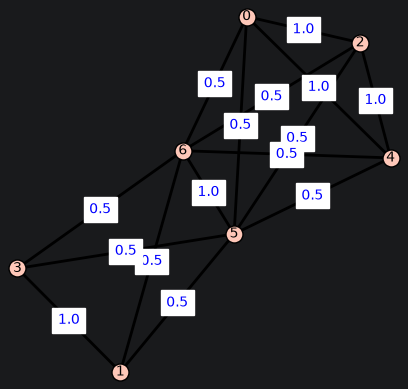

Square Roots
Number of labelled square roots: 6
Number of non-isomorphic square roots: 3

------------------------------------------------------------
Non-isomorphic square root 1
------------------------------------------------------------
Edges: [(0, 2), (0, 4), (0, 5), (1, 3), (1, 6), (2, 4), (3, 5), (4, 6), (5, 6)]


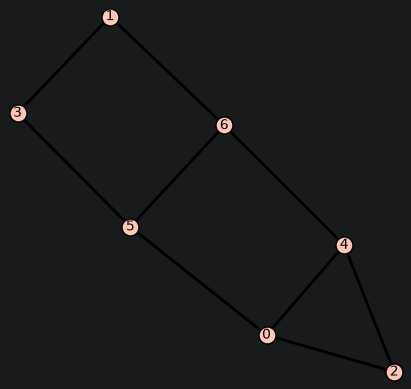


------------------------------------------------------------
Non-isomorphic square root 2
------------------------------------------------------------
Edges: [(0, 2), (0, 5), (1, 3), (1, 6), (2, 4), (3, 5), (4, 6), (5, 6)]


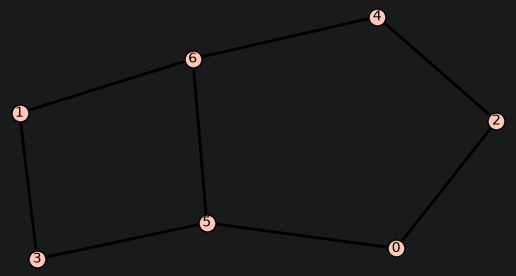


------------------------------------------------------------
Non-isomorphic square root 3
------------------------------------------------------------
Edges: [(0, 3), (0, 5), (1, 4), (1, 6), (2, 5), (3, 6), (4, 5), (5, 6)]


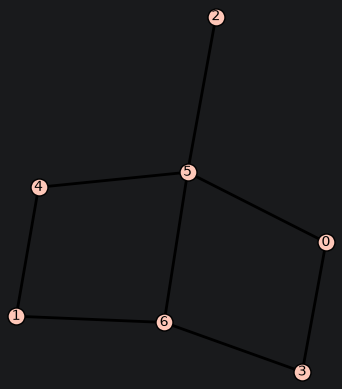

In [9]:
display_graph(1013, 7)